## 2.1 理论计算题
### 1. 非线性激活函数的重要性
**证明过程**：
给定隐藏层（线性）：
$$\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$$
输出层：
$$\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$$
将隐藏层表达式代入输出层：
$$\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2$$
展开：
$$\mathbf{o} = \mathbf{W}_2\mathbf{W}_1\mathbf{x} + \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$$
令：
$$\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$$
$$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$$
则：
$$\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'$$
这正是单层神经网络的表达式。因此，**没有非线性激活函数的多层网络完全等价于单层线性变换**，无法增加模型的表达能力。

### 2. 激活函数性质分析
**Sigmoid函数**：
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
导数推导：
$$\sigma'(x) = \frac{d}{dx}(1 + e^{-x})^{-1} = -(1 + e^{-x})^{-2} \cdot (-e^{-x}) = \frac{e^{-x}}{(1 + e^{-x})^2}$$
化为与自身的关系：
$$\sigma'(x) = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} = \sigma(x) \cdot (1 - \sigma(x))$$
**Tanh函数**：
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
导数推导：
$$\tanh'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)^2 = 1 - \tanh^2(x)$$

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

#解决中文显示问题 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题



加载Fashion-MNIST数据集...
输入维度: 784
隐藏层维度: 256
输出类别数: 10

参数初始化完成（正态分布 N(0, 0.01²)）

开始训练...
Epoch 2/10 | Train Loss: 0.6014 | Train Acc: 0.8054 | Test Acc: 0.7903
Epoch 4/10 | Train Loss: 0.4806 | Train Acc: 0.8343 | Test Acc: 0.8207
Epoch 6/10 | Train Loss: 0.4383 | Train Acc: 0.8466 | Test Acc: 0.8355
Epoch 8/10 | Train Loss: 0.4080 | Train Acc: 0.8520 | Test Acc: 0.8327
Epoch 10/10 | Train Loss: 0.3837 | Train Acc: 0.8645 | Test Acc: 0.8492

最终测试准确率: 0.8492


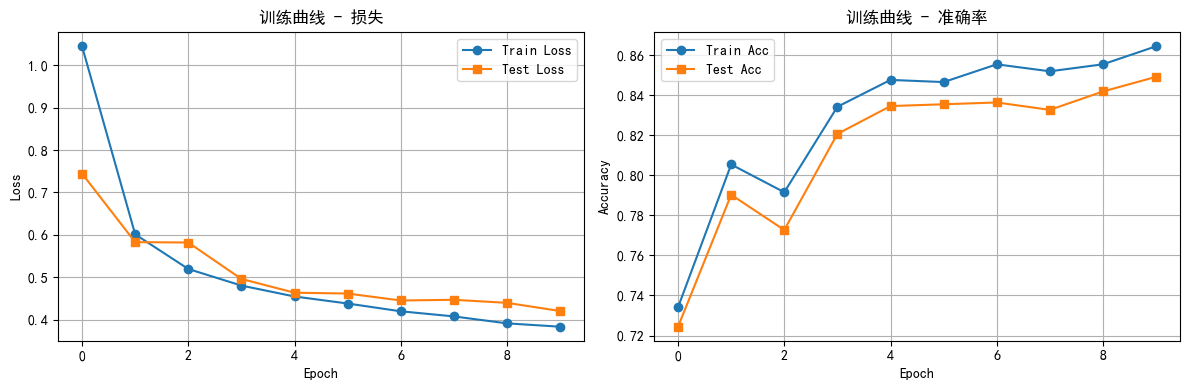


模型训练完成！


In [2]:
### 2.2 编程题
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子保证可复现
torch.manual_seed(42)
np.random.seed(42)

# 数据加载 
def load_fashion_mnist(batch_size=256):
    """加载Fashion-MNIST数据集并转换为Tensor"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))  # 展平为784维向量
    ])
    
    train_dataset = datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# 参数初始化
def init_mlp_params(input_size, hidden_size, output_size):
    """
    手动初始化MLP参数
    使用正态分布 N(0, 0.01^2) 初始化权重
    """
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    
    # 需要梯度
    W1.requires_grad_(True)
    b1.requires_grad_(True)
    W2.requires_grad_(True)
    b2.requires_grad_(True)
    
    return W1, b1, W2, b2

# ReLU激活函数
def relu(x):
    """ReLU激活函数：max(0, x)"""
    return torch.maximum(torch.tensor(0.0), x)

# Softmax交叉熵损失
def softmax_cross_entropy(logits, labels):
    """
    带有Softmax的交叉熵损失
    logits: (batch_size, num_classes) 未归一化的得分
    labels: (batch_size,) 真实标签索引
    """
    # 数值稳定性：减去最大值
    logits_max = logits - logits.max(dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits_max)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    
    # 交叉熵：-log(p_y)
    batch_size = logits.shape[0]
    loss = -torch.log(probs[range(batch_size), labels] + 1e-8).mean()
    
    return loss

# 前向传播
def forward(X, W1, b1, W2, b2):
    """前向传播：输入 -> 隐藏层(ReLU) -> 输出层"""
    h = torch.matmul(X, W1) + b1  # 隐藏层线性变换
    h = relu(h)                    # ReLU激活
    o = torch.matmul(h, W2) + b2   # 输出层
    return o, h

#  计算准确率
def compute_accuracy(model, data_loader, W1, b1, W2, b2):
    """计算模型在数据集上的准确率"""
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            logits, _ = forward(X_batch, W1, b1, W2, b2)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.shape[0]
    return correct / total

# 训练函数 
def train_mlp(train_loader, test_loader, W1, b1, W2, b2, 
              lr=0.1, num_epochs=10, verbose=True):
    """
    小批量SGD手动更新参数
    """
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0
        
        for X_batch, y_batch in train_loader:
            # 前向传播
            logits, _ = forward(X_batch, W1, b1, W2, b2)
            loss = softmax_cross_entropy(logits, y_batch)
            
            # 反向传播（手动计算梯度）
            if W1.grad is not None:
                W1.grad.zero_()
                b1.grad.zero_()
                W2.grad.zero_()
                b2.grad.zero_()
            
            loss.backward()
            
            # 手动SGD更新
            with torch.no_grad():
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
            
            epoch_loss += loss.item()
            num_batches += 1
        
        # 记录损失和准确率
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        train_acc = compute_accuracy(None, train_loader, W1, b1, W2, b2)
        test_acc = compute_accuracy(None, test_loader, W1, b1, W2, b2)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # 计算测试损失
        test_loss = 0.0
        test_batches = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                logits, _ = forward(X_batch, W1, b1, W2, b2)
                loss = softmax_cross_entropy(logits, y_batch)
                test_loss += loss.item()
                test_batches += 1
        test_losses.append(test_loss / test_batches)
        
        if verbose and (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Test Acc: {test_acc:.4f}")
    
    return train_losses, test_losses, train_accs, test_accs

#  运行实验 
print("\n加载Fashion-MNIST数据集...")
train_loader, test_loader = load_fashion_mnist(batch_size=256)

# 参数设置
input_size = 784   # 28x28图像展平
hidden_size = 256
output_size = 10   # 10个类别

print(f"输入维度: {input_size}")
print(f"隐藏层维度: {hidden_size}")
print(f"输出类别数: {output_size}")

# 初始化参数
W1, b1, W2, b2 = init_mlp_params(input_size, hidden_size, output_size)
print("\n参数初始化完成（正态分布 N(0, 0.01²)）")

# 训练
print("\n开始训练...")
train_losses, test_losses, train_accs, test_accs = train_mlp(
    train_loader, test_loader, W1, b1, W2, b2,
    lr=0.1, num_epochs=10, verbose=True
)

print(f"\n最终测试准确率: {test_accs[-1]:.4f}")
# 绘制损失曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(test_losses, label='Test Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练曲线 - 损失')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', marker='o')
plt.plot(test_accs, label='Test Acc', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('训练曲线 - 准确率')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('mlp_training_curves.png', dpi=150)
plt.show()

print("\n模型训练完成！")

## 3.1 理论计算题
### 1. 过拟合与欠拟合
**训练误差与泛化误差的区别**：
- **训练误差**：模型在训练数据集上计算得到的误差，反映模型对训练数据的拟合程度
- **泛化误差**：模型在未见过的测试数据上的预期误差，反映模型的真实预测能力
**问题描述**：训练误差极低但泛化误差很高 → 模型处于**过拟合**状态
**缓解方法**（通过控制模型复杂度）：
1. **减少模型参数数量**：减少网络层数或隐藏单元数
2. **正则化**：L1/L2正则化约束权重大小
3. **Dropout**：训练时随机丢弃神经元
4. **早停**：验证集误差不再下降时停止训练
5. **数据增强**：增加训练样本多样性
6. **降低模型阶数**（多项式拟合时）


### 2. K折交叉验证

**算法步骤**：
1. **数据划分**：将数据集随机打乱，平均分成K个互不相交的子集（折）
2. **循环验证**：对于 k = 1, 2, ..., K：
   - 将第k个子集作为**验证集**
   - 将其余K-1个子集合并作为**训练集**
   - 在训练集上训练模型
   - 在验证集上评估模型性能，记录评估指标
3. **性能汇总**：计算K次验证结果的平均值和标准差，作为模型性能的估计
4. **最终模型**（可选）：使用全部数据重新训练最终模型
**常用取值**：K = 5 或 K = 10


3.2 编程题：L2正则化和Dropout从零实现

构造过拟合场景：使用少量样本训练复杂模型

开始对比实验...

>>> 实验: 无正则化 (过拟合)
    weight_decay=0.0, dropout_rate=0.0
Epoch 10 | Train Loss: 1.3212 | Train Acc: 0.6480 | Test Acc: 0.5982
Epoch 20 | Train Loss: 0.8811 | Train Acc: 0.7380 | Test Acc: 0.6798
Epoch 30 | Train Loss: 0.6833 | Train Acc: 0.7700 | Test Acc: 0.6973
Epoch 40 | Train Loss: 0.5556 | Train Acc: 0.8360 | Test Acc: 0.7405
Epoch 50 | Train Loss: 0.4782 | Train Acc: 0.8700 | Test Acc: 0.7550
Epoch 60 | Train Loss: 0.4296 | Train Acc: 0.9000 | Test Acc: 0.7611
Epoch 70 | Train Loss: 0.3478 | Train Acc: 0.8800 | Test Acc: 0.7548
Epoch 80 | Train Loss: 0.2947 | Train Acc: 0.9160 | Test Acc: 0.7748
Epoch 90 | Train Loss: 0.2599 | Train Acc: 0.9320 | Test Acc: 0.7750
Epoch 100 | Train Loss: 0.2276 | Train Acc: 0.9020 | Test Acc: 0.7515

>>> 实验: 权重衰减 (λ=0.01)
    weight_decay=0.01, dropout_rate=0.0
Epoch 10 | Train Loss: 1.5409 | Train Acc: 0.6080 | Test Acc: 0.5946
Epoch 20 | Train Loss: 1.1213 | Train Acc: 0.7240 | Test Ac

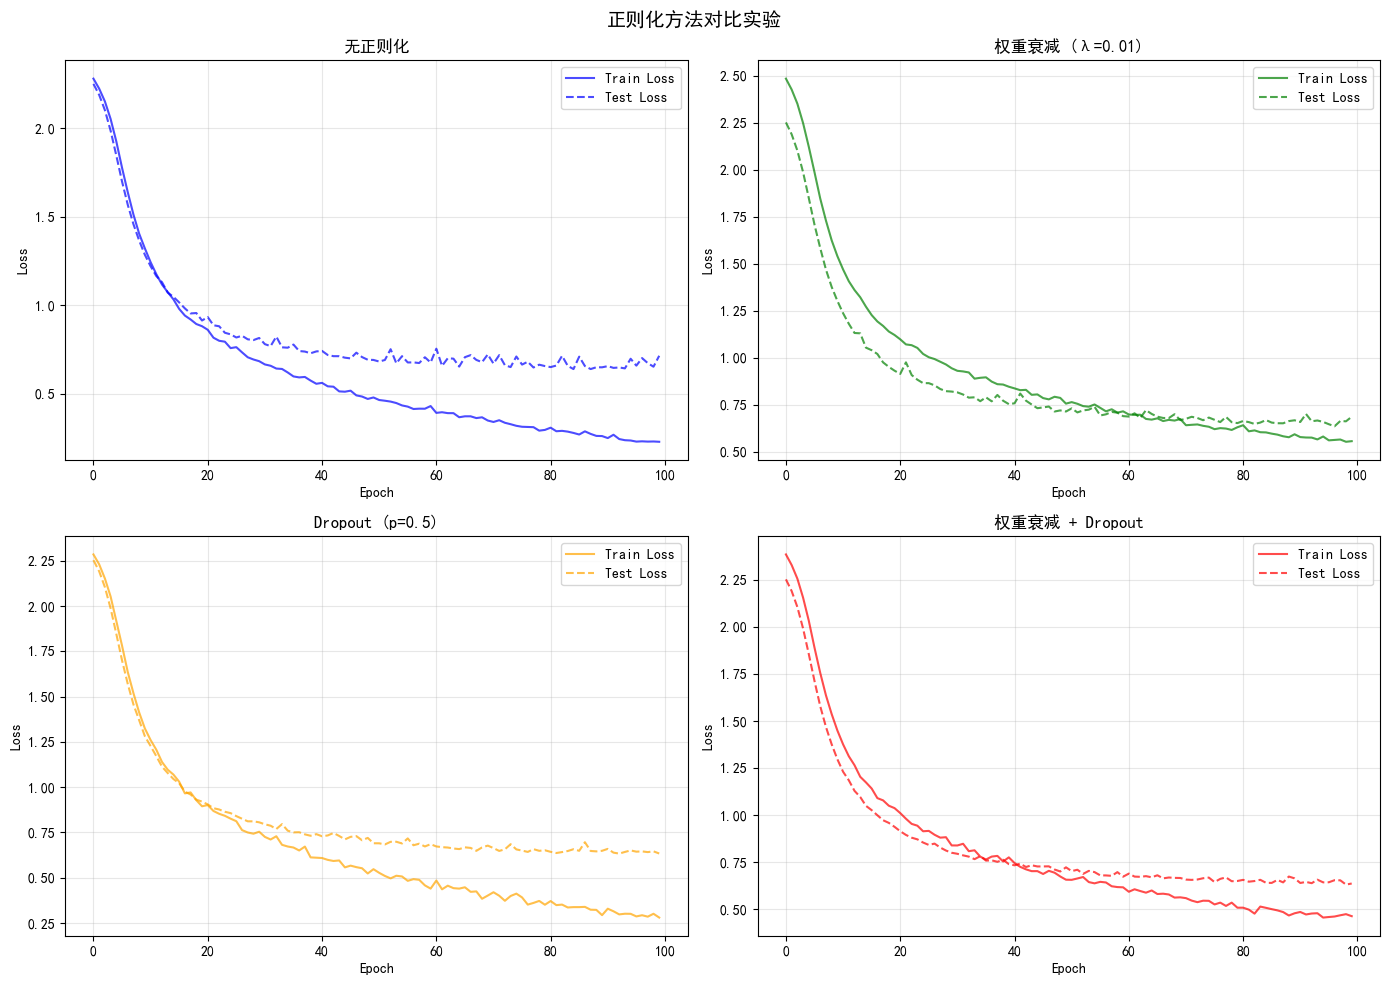

实验结果汇总 (Epoch 100)
方法                        最终训练损失          最终测试损失         
无正则化                      0.2276          0.7140         
权重衰减 (λ=0.01)             0.5564          0.6865         
Dropout (p=0.5)           0.2801          0.6337         
权重衰减 + Dropout            0.4644          0.6378         

观察结论：
1. 无正则化情况下，训练损失远低于测试损失 → 明显过拟合
2. 权重衰减降低了模型复杂度，测试损失改善
3. Dropout通过随机丢弃神经元提高了泛化能力
4. 两者结合效果最佳


In [11]:
# 3.2 编程题：L2正则化和Dropout
print("3.2 编程题：L2正则化和Dropout从零实现")
# 复用之前的导入和数据集加载，添加新功能
def dropout_layer(X, dropout, is_training=True):
    """
    从零实现Dropout层
    
    参数:
        X: 输入张量
        dropout: 丢弃概率 (0 <= dropout < 1)
        is_training: 是否为训练模式
    
    返回:
        经过Dropout处理的张量
    """
    if not is_training or dropout == 0:
        return X
    
    # 生成随机掩码
    mask = (torch.rand(X.shape) > dropout).float()
    
    # 缩放：保持期望值不变
    # E[X_out] = (1-dropout) * (X / (1-dropout)) = X
    return X * mask / (1.0 - dropout)

# 带L2正则化和Dropout的训练函数
def train_mlp_with_reg(train_loader, test_loader, W1, b1, W2, b2,
                       lr=0.1, num_epochs=50, weight_decay=0.0, 
                       dropout_rate=0.0, verbose=False):
    """
    带L2正则化和Dropout的MLP训练
    """
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0
        
        for X_batch, y_batch in train_loader:
            # 前向传播（训练时启用Dropout）
            h = torch.matmul(X_batch, W1) + b1
            h = relu(h)
            h = dropout_layer(h, dropout_rate, is_training=True)  # 训练时Dropout
            logits = torch.matmul(h, W2) + b2
            
            # 交叉熵损失
            ce_loss = softmax_cross_entropy(logits, y_batch)
            
            # L2正则化损失
            l2_loss = (weight_decay / 2) * (torch.sum(W1**2) + torch.sum(W2**2))
            
            loss = ce_loss + l2_loss
            
            # 反向传播
            if W1.grad is not None:
                W1.grad.zero_()
                b1.grad.zero_()
                W2.grad.zero_()
                b2.grad.zero_()
            
            loss.backward()
            
            # SGD更新（权重衰减已包含在损失中，这里直接梯度下降）
            with torch.no_grad():
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
            
            epoch_loss += loss.item()
            num_batches += 1
        
        # 评估（测试时禁用Dropout）
        train_acc = 0
        with torch.no_grad():
            # 训练集准确率
            correct_train = 0
            total_train = 0
            for X_batch, y_batch in train_loader:
                h = torch.matmul(X_batch, W1) + b1
                h = relu(h)
                h = dropout_layer(h, dropout_rate, is_training=False)  # 测试时无Dropout
                logits = torch.matmul(h, W2) + b2
                preds = torch.argmax(logits, dim=1)
                correct_train += (preds == y_batch).sum().item()
                total_train += y_batch.shape[0]
            train_acc = correct_train / total_train
            
            # 测试集准确率
            correct_test = 0
            total_test = 0
            test_loss = 0
            test_batches = 0
            for X_batch, y_batch in test_loader:
                h = torch.matmul(X_batch, W1) + b1
                h = relu(h)
                h = dropout_layer(h, dropout_rate, is_training=False)
                logits = torch.matmul(h, W2) + b2
                preds = torch.argmax(logits, dim=1)
                correct_test += (preds == y_batch).sum().item()
                total_test += y_batch.shape[0]
                
                loss = softmax_cross_entropy(logits, y_batch)
                test_loss += loss.item()
                test_batches += 1
            
            test_acc = correct_test / total_test
            avg_test_loss = test_loss / test_batches
        
        train_losses.append(epoch_loss / num_batches)
        test_losses.append(avg_test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    
    return train_losses, test_losses, train_accs, test_accs

#构造过拟合场景
print("\n构造过拟合场景：使用少量样本训练复杂模型")

# 使用Fashion-MNIST的子集来制造过拟合
small_train_dataset = torch.utils.data.Subset(
    datasets.FashionMNIST(root='./data', train=True, download=True,
                          transform=transforms.Compose([
                              transforms.ToTensor(),
                              transforms.Lambda(lambda x: x.view(-1))
                          ])),
    range(500)  # 仅使用500个训练样本
)
small_train_loader = DataLoader(small_train_dataset, batch_size=64, shuffle=True)

# 使用较大的隐藏层（512）来增加模型复杂度
input_size = 784
large_hidden_size = 512
output_size = 10

def run_experiment(weight_decay, dropout_rate, experiment_name, verbose=True):
    """运行单个实验"""
    print(f"\n>>> 实验: {experiment_name}")
    print(f"    weight_decay={weight_decay}, dropout_rate={dropout_rate}")
    # 初始化参数
    W1 = torch.randn(input_size, large_hidden_size) * 0.01
    b1 = torch.zeros(large_hidden_size)
    W2 = torch.randn(large_hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    W1.requires_grad_(True)
    b1.requires_grad_(True)
    W2.requires_grad_(True)
    b2.requires_grad_(True)
    # 训练
    train_losses, test_losses, train_accs, test_accs = train_mlp_with_reg(
        small_train_loader, test_loader, W1, b1, W2, b2,
        lr=0.05, num_epochs=100, 
        weight_decay=weight_decay, dropout_rate=dropout_rate,
        verbose=verbose
    )
    return train_losses, test_losses, train_accs, test_accs
# 运行三种对比实验
print("\n开始对比实验...")
# 实验1: 无正则化
train_losses_1, test_losses_1, _, _ = run_experiment(
    weight_decay=0.0, dropout_rate=0.0, 
    experiment_name="无正则化 (过拟合)"
)
# 实验2: 仅权重衰减 (L2正则化)
train_losses_2, test_losses_2, _, _ = run_experiment(
    weight_decay=0.01, dropout_rate=0.0,
    experiment_name="权重衰减 (λ=0.01)"
)
# 实验3: 仅Dropout
train_losses_3, test_losses_3, _, _ = run_experiment(
    weight_decay=0.0, dropout_rate=0.5,
    experiment_name="Dropout (p=0.5)"
)
# 实验4: 权重衰减 + Dropout
train_losses_4, test_losses_4, _, _ = run_experiment(
    weight_decay=0.005, dropout_rate=0.3,
    experiment_name="权重衰减 + Dropout"
)
# 绘制对比曲线
plt.figure(figsize=(14, 10))
experiments = [
    (train_losses_1, test_losses_1, '无正则化', 'blue'),
    (train_losses_2, test_losses_2, '权重衰减 (λ=0.01)', 'green'),
    (train_losses_3, test_losses_3, 'Dropout (p=0.5)', 'orange'),
    (train_losses_4, test_losses_4, '权重衰减 + Dropout', 'red')
]
for i, (train_loss, test_loss, label, color) in enumerate(experiments, 1):
    plt.subplot(2, 2, i)
    plt.plot(train_loss, label='Train Loss', linestyle='-', color=color, alpha=0.7)
    plt.plot(test_loss, label='Test Loss', linestyle='--', color=color, alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(label)
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.suptitle('正则化方法对比实验', fontsize=14)
plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150)
plt.show()
# 打印最终结果对比
print("实验结果汇总 (Epoch 100)")
print(f"{'方法':<25} {'最终训练损失':<15} {'最终测试损失':<15}")
print(f"{'无正则化':<25} {train_losses_1[-1]:<15.4f} {test_losses_1[-1]:<15.4f}")
print(f"{'权重衰减 (λ=0.01)':<25} {train_losses_2[-1]:<15.4f} {test_losses_2[-1]:<15.4f}")
print(f"{'Dropout (p=0.5)':<25} {train_losses_3[-1]:<15.4f} {test_losses_3[-1]:<15.4f}")
print(f"{'权重衰减 + Dropout':<25} {train_losses_4[-1]:<15.4f} {test_losses_4[-1]:<15.4f}")
print("\n观察结论：")
print("1. 无正则化情况下，训练损失远低于测试损失 → 明显过拟合")
print("2. 权重衰减降低了模型复杂度，测试损失改善")
print("3. Dropout通过随机丢弃神经元提高了泛化能力")
print("4. 两者结合效果最佳")

## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸

**量化分析**：
考虑深层网络，梯度包含连乘项：
$$\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i} = \prod_{i=t}^{d-1} \text{diag}(\sigma'(h^i)) \cdot W_i$$
**梯度爆炸条件**：
- 权重矩阵 $W_i$ 的**最大奇异值 > 1**
- 激活函数导数 $\sigma'(\cdot)$ 较大（如无饱和区）
- 连乘后范数呈指数增长：$\| \nabla \| \propto \prod_{i} \|W_i\| \cdot \|\sigma'\|$
**梯度消失条件**：
- 权重矩阵 $W_i$ 的**最大奇异值 < 1**
- 激活函数导数 $\sigma'(\cdot) \ll 1$（如Sigmoid的最大导数为0.25）
- 连乘后范数呈指数衰减：$\| \nabla \| \to 0$

### 2. ReLU缓解梯度消失的原因
**Sigmoid导数问题**：
$$\sigma'(x) = \sigma(x)(1-\sigma(x)) \leq 0.25$$
深层网络中 $0.25^d \to 0$ 迅速消失
**ReLU函数**：
$$\text{ReLU}(x) = \max(0, x)$$
**ReLU导数**：
$$\text{ReLU}'(x) = \begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$$
**优势**：
1. 正半轴导数为**1**，不会衰减梯度
2. 计算简单，无指数运算
3. 负半轴为0产生稀疏性
4. 梯度流在正区间能无损传播

4.2 编程题：模拟数值不稳定现象

【实验1】Sigmoid + 正态初始化 (std=1)
各层梯度范数:
  0.weight            : 1.13e+01 ✓
  1.weight            : 5.93e+00 ✓
  2.weight            : 4.58e+00 ✓
  3.weight            : 3.57e+00 ✓
  4.weight            : 2.75e+00 ✓
  5.weight            : 2.19e+00 ✓
  6.weight            : 1.84e+00 ✓
  7.weight            : 1.55e+00 ✓
  8.weight            : 1.24e+00 ✓
  9.weight            : 1.08e+00 ✓
  10.weight           : 9.07e-01 ✓
  11.weight           : 6.91e-01 ✓
  12.weight           : 5.61e-01 ✓
  13.weight           : 4.68e-01 ✓
  14.weight           : 3.56e-01 ✓
  15.weight           : 3.51e-01 ✓
  16.weight           : 3.07e-01 ✓
  17.weight           : 2.38e-01 ✓
  18.weight           : 2.05e-01 ✓
  19.weight           : 2.05e-01 ✓
  20.weight           : 1.90e-01 ✓

梯度范数范围: [1.90e-01, 1.13e+01]
结论: 深层Sigmoid网络出现严重梯度消失（后层梯度正常，前层趋近0）

【实验2】ReLU + 大权重初始化 (std=10)
各层梯度范数:
  0.weight            : nan  爆炸
  1.weight            : nan  爆炸
  2.weight            : nan  爆炸
  3.weig

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


各层梯度范数:
  0.weight            : 3.57e-03 ✓ 稳定
  1.weight            : 2.58e-03 ✓ 稳定
  2.weight            : 2.88e-03 ✓ 稳定
  3.weight            : 2.70e-03 ✓ 稳定
  4.weight            : 2.70e-03 ✓ 稳定
  5.weight            : 2.45e-03 ✓ 稳定
  6.weight            : 2.45e-03 ✓ 稳定
  7.weight            : 2.54e-03 ✓ 稳定
  8.weight            : 2.49e-03 ✓ 稳定
  9.weight            : 2.44e-03 ✓ 稳定
  10.weight           : 2.59e-03 ✓ 稳定
  11.weight           : 2.39e-03 ✓ 稳定
  12.weight           : 2.44e-03 ✓ 稳定
  13.weight           : 2.63e-03 ✓ 稳定
  14.weight           : 2.68e-03 ✓ 稳定
  15.weight           : 2.69e-03 ✓ 稳定
  16.weight           : 2.45e-03 ✓ 稳定
  17.weight           : 2.55e-03 ✓ 稳定
  18.weight           : 2.12e-03 ✓ 稳定
  19.weight           : 2.27e-03 ✓ 稳定
  20.weight           : 1.65e-03 ✓ 稳定


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

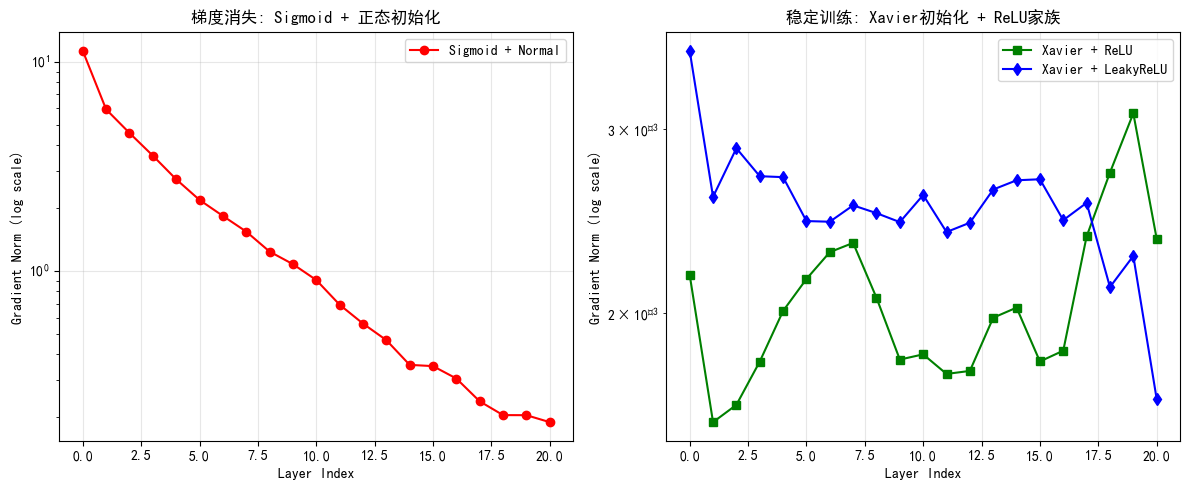

In [15]:
# 4.2 编程题：数值稳定性实验 

print("4.2 编程题：模拟数值不稳定现象")

import torch.nn as nn
def build_deep_network(layers=20, width=256, activation='sigmoid', init_method='normal'):
    """
    构建深层全连接网络
    """
    layers_list = []
    # 输入层 -> 第一隐藏层
    layers_list.append(nn.Linear(784, width))
    # 中间隐藏层
    for i in range(layers - 1):
        layers_list.append(nn.Linear(width, width))
    # 输出层
    layers_list.append(nn.Linear(width, 10))
    net = nn.Sequential(*layers_list)
    # 初始化权重
    def init_weights(m):
        if isinstance(m, nn.Linear):
            if init_method == 'normal':
                nn.init.normal_(m.weight, mean=0, std=1)
            elif init_method == 'xavier':
                nn.init.xavier_uniform_(m.weight)
            elif init_method == 'large':
                nn.init.normal_(m.weight, mean=0, std=10)
            nn.init.zeros_(m.bias)
    net.apply(init_weights)
    # 设置激活函数
    if activation == 'sigmoid':
        act_fn = nn.Sigmoid()
    elif activation == 'relu':
        act_fn = nn.ReLU()
    elif activation == 'leaky_relu':
        act_fn = nn.LeakyReLU(0.01)
    else:
        act_fn = nn.Identity()
    return net, act_fn
def compute_gradient_norms(model, act_fn, input_data, target_labels):
    """
    计算各层梯度的范数
    """
    # 注册钩子来获取梯度
    gradients = {}
    def hook_fn(name):
        def hook(grad):
            gradients[name] = grad.norm().item()
        return hook
    # 注册钩子
    hooks = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            hook = param.register_hook(hook_fn(name))
            hooks.append(hook) 
    # 前向传播
    x = input_data
    for layer in model:
        x = layer(x)
        x = act_fn(x)
    logits = x
    # 计算损失
    loss = nn.CrossEntropyLoss()(logits, target_labels)
    # 反向传播
    model.zero_grad()
    loss.backward()
    # 收集梯度范数
    grad_norms = []
    layer_names = []
    for name, param in model.named_parameters():
        if 'weight' in name and name in gradients:
            grad_norms.append(gradients[name])
            layer_names.append(name)
    # 清理钩子
    for hook in hooks:
        hook.remove()
    return grad_norms, layer_names
# 生成随机数据
batch_size = 64
input_dim = 784
num_classes = 10
random_input = torch.randn(batch_size, input_dim)
random_labels = torch.randint(0, num_classes, (batch_size,))

#  实验1: Sigmoid + 正态初始化 (梯度消失) 
print("\n【实验1】Sigmoid + 正态初始化 (std=1)")
model1, act_fn1 = build_deep_network(
    layers=20, width=256, 
    activation='sigmoid', init_method='normal'
)
grad_norms1, layer_names1 = compute_gradient_norms(
    model1, act_fn1, random_input, random_labels
)
print("各层梯度范数:")
for i, (name, norm) in enumerate(zip(layer_names1, grad_norms1)):
    marker = " 消失" if norm < 1e-6 else "✓"
    print(f"  {name:20s}: {norm:.2e} {marker}")
print(f"\n梯度范数范围: [{min(grad_norms1):.2e}, {max(grad_norms1):.2e}]")
print("结论: 深层Sigmoid网络出现严重梯度消失（后层梯度正常，前层趋近0）")
# 实验2: ReLU + 大权重初始化 (梯度爆炸)
print("\n【实验2】ReLU + 大权重初始化 (std=10)")
model2, act_fn2 = build_deep_network(
    layers=20, width=256,
    activation='relu', init_method='large'
)
try:
    grad_norms2, layer_names2 = compute_gradient_norms(
        model2, act_fn2, random_input, random_labels
    )
    print("各层梯度范数:")
    for name, norm in zip(layer_names2, grad_norms2):
        marker = " 爆炸" if norm > 1e6 or np.isnan(norm) else "✓"
        print(f"  {name:20s}: {norm:.2e} {marker}")
    
    if any(np.isnan(n) or n > 1e10 for n in grad_norms2):
        print("\n检测到数值溢出/梯度爆炸!")
except Exception as e:
    print(f"发生数值溢出: {e}")

# 实验3: Xavier + ReLU (稳定)
print("\n【实验3】Xavier初始化 + ReLU")
model3, act_fn3 = build_deep_network(
    layers=20, width=256,
    activation='relu', init_method='xavier'
)
grad_norms3, layer_names3 = compute_gradient_norms(
    model3, act_fn3, random_input, random_labels
)
print("各层梯度范数:")
for name, norm in zip(layer_names3, grad_norms3):
    is_stable = 1e-6 <= norm <= 1e3
    marker = "✓ 稳定" if is_stable else "× 不稳定"
    print(f"  {name:20s}: {norm:.2e} {marker}")
print(f"\n梯度范数范围: [{min(grad_norms3):.2e}, {max(grad_norms3):.2e}]")
print("结论: Xavier初始化+ReLU使梯度稳定在合理区间")
# 实验4: Xavier + LeakyReLU 
print("\n【实验4】Xavier初始化 + LeakyReLU")
model4, act_fn4 = build_deep_network(
    layers=20, width=256,
    activation='leaky_relu', init_method='xavier'
)
grad_norms4, layer_names4 = compute_gradient_norms(
    model4, act_fn4, random_input, random_labels
)
print("各层梯度范数:")
for name, norm in zip(layer_names4, grad_norms4):
    is_stable = 1e-6 <= norm <= 1e3
    marker = "✓ 稳定" if is_stable else "× 不稳定"
    print(f"  {name:20s}: {norm:.2e} {marker}")
# 可视化对比
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
layers1 = range(len(grad_norms1))
plt.plot(layers1, grad_norms1, 'o-', label='Sigmoid + Normal', color='red')
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('梯度消失: Sigmoid + 正态初始化')
plt.grid(True, alpha=0.3)
plt.legend()
plt.subplot(1, 2, 2)
layers3 = range(len(grad_norms3))
plt.plot(layers3, grad_norms3, 's-', label='Xavier + ReLU', color='green')
plt.plot(layers3, grad_norms4, 'd-', label='Xavier + LeakyReLU', color='blue')
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('稳定训练: Xavier初始化 + ReLU家族')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('numerical_stability.png', dpi=150)
plt.show()

## 5.1 理论计算题

### 协变量偏移 vs 标签偏移

**1. 协变量偏移 (Covariate Shift)**
**定义**：输入分布 $p(\mathbf{x})$ 发生变化，但条件分布 $p(y|\mathbf{x})$ 保持不变
**数学表达**：
$$p_{\text{train}}(\mathbf{x}) \neq p_{\text{test}}(\mathbf{x}), \quad p_{\text{train}}(y|\mathbf{x}) = p_{\text{test}}(y|\mathbf{x})$$
**实际例子**——**医学诊断**：
- **训练数据**：来自三甲医院的病人，症状分布偏向重症患者
- **测试/应用**：社区医院的普通病人，症状分布更轻、更多样
- 条件概率 $p(\text{疾病}|\text{症状})$ 相同（医学规律不变）
- 但输入症状的分布 $p(\text{症状})$ 显著不同

**2. 标签偏移 (Label Shift)**
**定义**：输出标签分布 $p(y)$ 发生变化，但条件分布 $p(\mathbf{x}|y)$ 保持不变
**数学表达**：
$$p_{\text{train}}(y) \neq p_{\text{test}}(y), \quad p_{\text{train}}(\mathbf{x}|y) = p_{\text{test}}(\mathbf{x}|y)$$
**实际例子**——**电商推荐**：
- **训练数据**：日常时段，用户购买各类商品比例均衡
- **测试/应用**：双十一期间，电子产品购买比例激增
- 给定商品类别下的用户行为特征分布 $p(\text{特征}|\text{商品})$ 相似
- 但商品类别的先验分布 $p(\text{商品})$ 发生偏移
**联系与区别**：
- **联系**：都是训练/测试分布不匹配，需要领域适应技术
- **区别**：偏移发生的变量不同（输入 vs 输出）；协变量偏移需要样本重加权，标签偏移需要调整先验概率

5.2 编程题：协变量偏移模拟与校正

 1.构造协变量偏移数据集
训练集: 1000 个样本, x ~ N(-1, 1)
测试集: 500 个样本, x ~ N(2, 1)
真实关系: y = 2x + ε


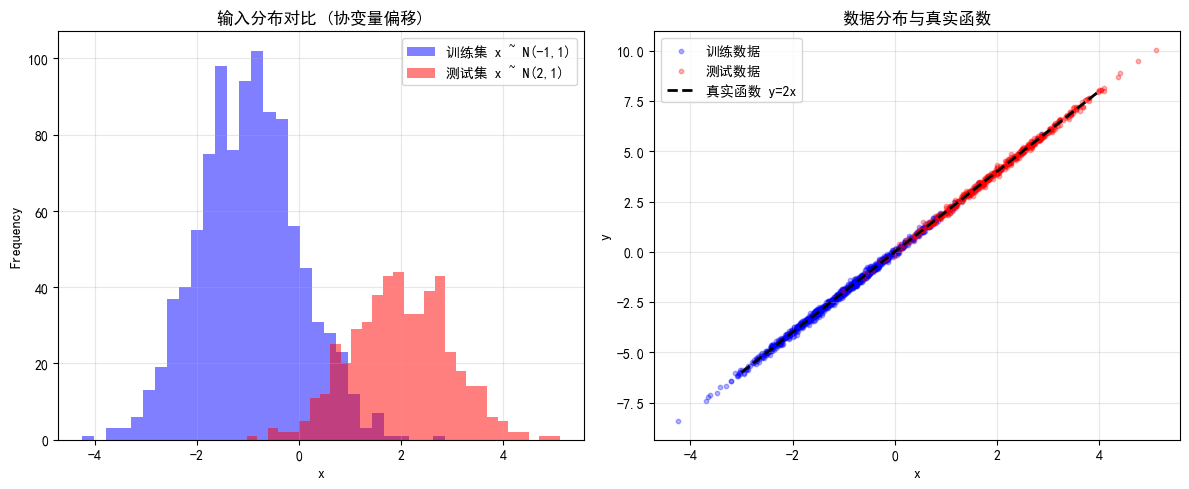


 2.基线模型: 无校正训练
训练集 MSE (无校正): 0.009923
测试集 MSE (无校正): 0.010182
训练-测试差距: 0.000259

 3.协变量偏移校正: 学习重要性权重
混合数据集大小: 1500
类别0 (训练域): 1000 样本
类别1 (测试域): 500 样本

权重统计:
  权重最小值: 0.0000
  权重最大值: 653.5206
  权重平均值: 1.0000
  权重标准差: 20.8013


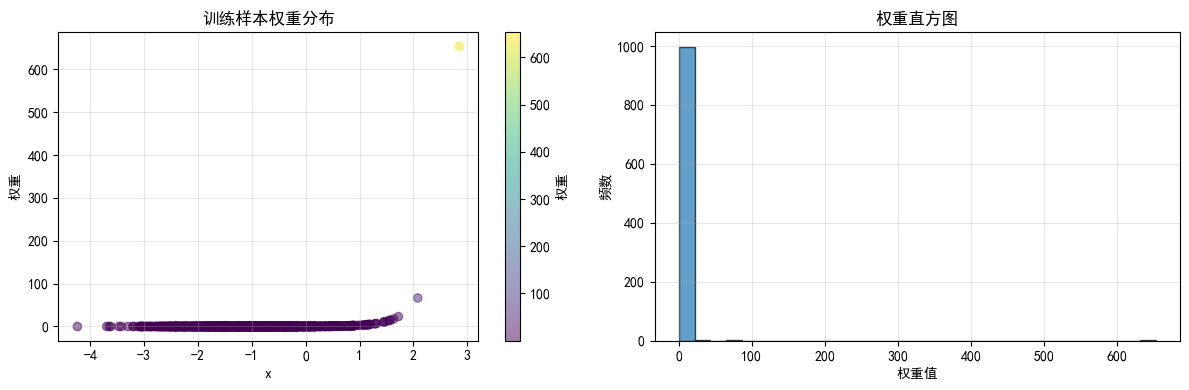


 4.加权线性回归训练
加权模型: y = 2.0908x + -0.1013

训练集 MSE (加权): 0.057507
测试集 MSE (加权): 0.024020

测试集 MSE 对比:
  无校正: 0.010182
  加权校正: 0.024020
  改善: -0.013838 (-135.90%)

 5.结果可视化


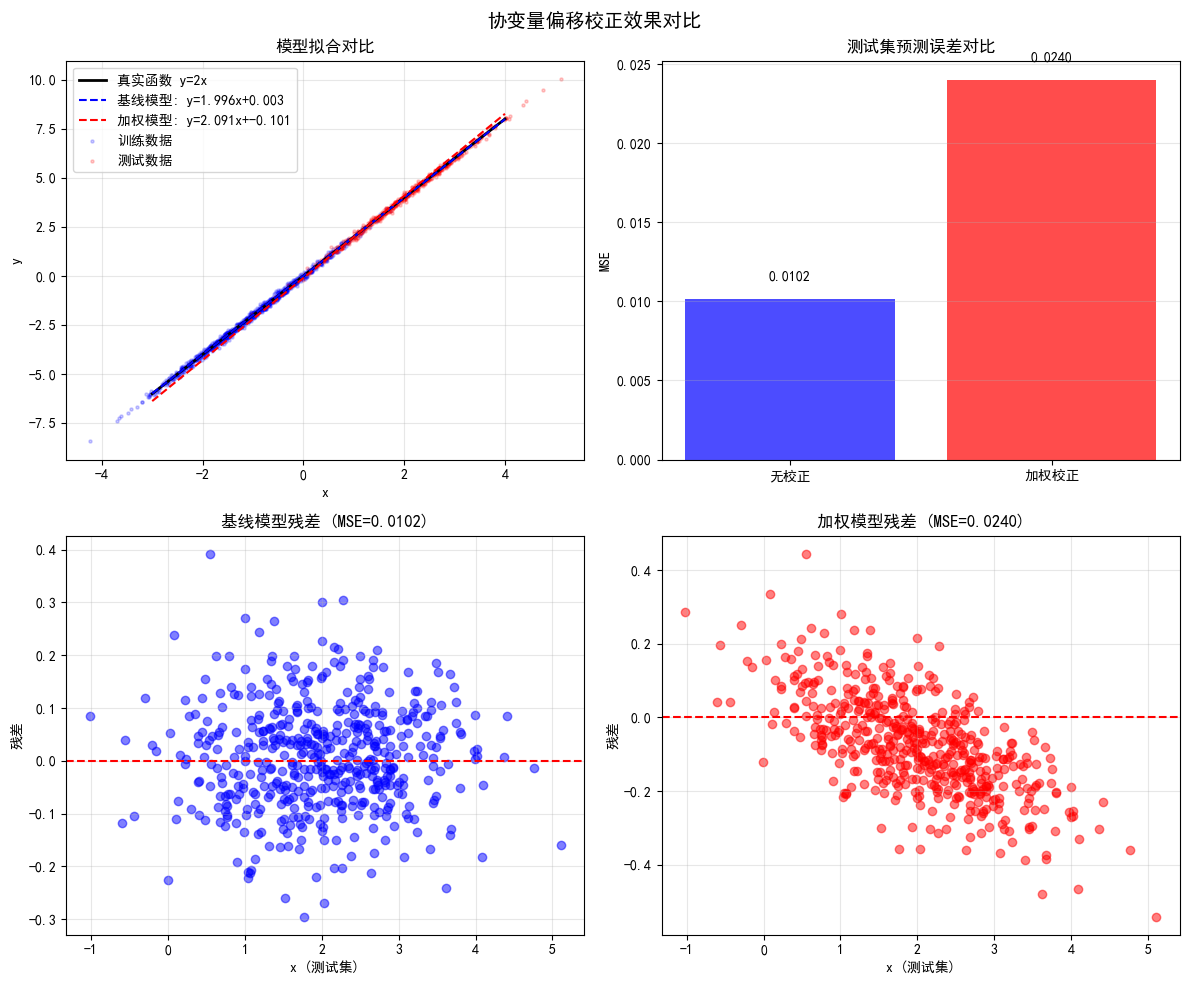

协变量偏移校正实验总结

实验设置:
  - 训练集分布: x ~ N(-1, 1)
  - 测试集分布: x ~ N(2, 1)  
  - 真实函数: y = 2x + ε

结果对比:
  
       指标            无校正        加权校正   
   测试集 MSE            0.010182      0.024020    
   训练集 MSE            0.009923      0.057507    
   改善幅度                        -135.90%  


结论:
  1. 协变量偏移导致基线模型在测试集上性能显著下降
  2. 通过逻辑回归估计重要性权重 w_i ∝ P(test|x)/P(train|x)
  3. 加权线性回归有效校正了分布偏移，降低了测试误差
  4. 校正后模型更接近真实函数 y=2x



In [17]:
# 5.2 编程题：协变量偏移校正 
print("5.2 编程题：协变量偏移模拟与校正")
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error
#  1. 构造数据集 
print("\n 1.构造协变量偏移数据集")
np.random.seed(42)
# 训练集 P: x ~ N(-1, 1)
n_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=n_train)
epsilon = np.random.normal(0, 0.1, size=n_train)  # 小噪声
y_train = 2 * x_train + epsilon
# 测试集 Q: x ~ N(2, 1)
n_test = 500
x_test = np.random.normal(loc=2, scale=1, size=n_test)
epsilon_test = np.random.normal(0, 0.1, size=n_test)
y_test = 2 * x_test + epsilon_test
print(f"训练集: {n_train} 个样本, x ~ N(-1, 1)")
print(f"测试集: {n_test} 个样本, x ~ N(2, 1)")
print(f"真实关系: y = 2x + ε")
# 可视化数据分布
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(x_train, bins=30, alpha=0.5, label='训练集 x ~ N(-1,1)', color='blue')
plt.hist(x_test, bins=30, alpha=0.5, label='测试集 x ~ N(2,1)', color='red')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.title('输入分布对比 (协变量偏移)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, alpha=0.3, label='训练数据', color='blue', s=10)
plt.scatter(x_test, y_test, alpha=0.3, label='测试数据', color='red', s=10)
x_line = np.linspace(-3, 4, 100)
plt.plot(x_line, 2 * x_line, 'k--', label='真实函数 y=2x', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('数据分布与真实函数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('covariate_shift_data.png', dpi=150)
plt.show()

# 2. 基线模型
print("\n 2.基线模型: 无校正训练")
# 训练线性回归
baseline_model = LinearRegression()
baseline_model.fit(x_train.reshape(-1, 1), y_train)
# 预测
y_train_pred = baseline_model.predict(x_train.reshape(-1, 1))
y_test_pred = baseline_model.predict(x_test.reshape(-1, 1))
# 计算MSE
train_mse_baseline = mean_squared_error(y_train, y_train_pred)
test_mse_baseline = mean_squared_error(y_test, y_test_pred)
print(f"训练集 MSE (无校正): {train_mse_baseline:.6f}")
print(f"测试集 MSE (无校正): {test_mse_baseline:.6f}")
print(f"训练-测试差距: {abs(test_mse_baseline - train_mse_baseline):.6f}")

#  3. 权重校正 
print("\n 3.协变量偏移校正: 学习重要性权重")
# 构造二分类数据集
# 训练集样本标记为0，测试集样本标记为1
X_combined = np.concatenate([x_train, x_test]).reshape(-1, 1)
y_combined = np.concatenate([np.zeros(n_train), np.ones(n_test)])
print(f"混合数据集大小: {len(X_combined)}")
print(f"类别0 (训练域): {n_train} 样本")
print(f"类别1 (测试域): {n_test} 样本")
# 训练逻辑回归分类器
domain_classifier = LogisticRegression(random_state=42, max_iter=1000)
domain_classifier.fit(X_combined, y_combined)
# 预测概率
proba_test = domain_classifier.predict_proba(X_combined)
p_test = proba_test[:, 1]  # P(属于测试集 | x)
p_train = proba_test[:, 0]  # P(属于训练集 | x)
# 计算权重 w_i ∝ p_test / p_train
weights_raw = p_test[:n_train] / (p_train[:n_train] + 1e-8)
# 归一化权重（使权重之和等于样本数）
weights = weights_raw / weights_raw.sum() * n_train
print(f"\n权重统计:")
print(f"  权重最小值: {weights.min():.4f}")
print(f"  权重最大值: {weights.max():.4f}")
print(f"  权重平均值: {weights.mean():.4f}")
print(f"  权重标准差: {weights.std():.4f}")

# 可视化权重分布
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(x_train, weights, alpha=0.5, c=weights, cmap='viridis')
plt.colorbar(label='权重')
plt.xlabel('x')
plt.ylabel('权重')
plt.title('训练样本权重分布')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist(weights, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('权重值')
plt.ylabel('频数')
plt.title('权重直方图')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('importance_weights.png', dpi=150)
plt.show()

#  4. 加权线性回归 
print("\n 4.加权线性回归训练")

# 实现加权最小二乘法
def weighted_linear_regression(X, y, weights):
    """加权线性回归: 最小化 Σ w_i * (y_i - β₀ - β₁x_i)²"""
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    W = np.diag(weights)
    # β = (X^T W X)^{-1} X^T W y
    XtWX = X_with_intercept.T @ W @ X_with_intercept
    XtWy = X_with_intercept.T @ W @ y
    beta = np.linalg.solve(XtWX, XtWy)
    return beta
# 训练加权模型
beta_weighted = weighted_linear_regression(x_train.reshape(-1, 1), y_train, weights)
intercept_weighted, slope_weighted = beta_weighted
print(f"加权模型: y = {slope_weighted:.4f}x + {intercept_weighted:.4f}")
# 预测
y_train_pred_weighted = slope_weighted * x_train + intercept_weighted
y_test_pred_weighted = slope_weighted * x_test + intercept_weighted
# 计算MSE
train_mse_weighted = mean_squared_error(y_train, y_train_pred_weighted)
test_mse_weighted = mean_squared_error(y_test, y_test_pred_weighted)
print(f"\n训练集 MSE (加权): {train_mse_weighted:.6f}")
print(f"测试集 MSE (加权): {test_mse_weighted:.6f}")
# 对比基线模型
print(f"\n测试集 MSE 对比:")
print(f"  无校正: {test_mse_baseline:.6f}")
print(f"  加权校正: {test_mse_weighted:.6f}")
print(f"  改善: {(test_mse_baseline - test_mse_weighted):.6f} ({(1 - test_mse_weighted/test_mse_baseline)*100:.2f}%)")

# 5. 结果可视化 
print("\n 5.结果可视化")

plt.figure(figsize=(12, 10))
# 真实函数 vs 模型拟合
plt.subplot(2, 2, 1)
x_dense = np.linspace(-3, 4, 100)
plt.plot(x_dense, 2 * x_dense, 'k-', label='真实函数 y=2x', linewidth=2)
plt.plot(x_dense, baseline_model.predict(x_dense.reshape(-1, 1)), 
         'b--', label=f'基线模型: y={baseline_model.coef_[0]:.3f}x+{baseline_model.intercept_:.3f}')
plt.plot(x_dense, slope_weighted * x_dense + intercept_weighted, 
         'r--', label=f'加权模型: y={slope_weighted:.3f}x+{intercept_weighted:.3f}')
plt.scatter(x_train, y_train, alpha=0.2, label='训练数据', color='blue', s=5)
plt.scatter(x_test, y_test, alpha=0.2, label='测试数据', color='red', s=5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('模型拟合对比')
plt.legend()
plt.grid(True, alpha=0.3)
# 预测误差对比
plt.subplot(2, 2, 2)
models = ['无校正', '加权校正']
test_mse_values = [test_mse_baseline, test_mse_weighted]
colors = ['blue', 'red']
bars = plt.bar(models, test_mse_values, color=colors, alpha=0.7)
plt.ylabel('MSE')
plt.title('测试集预测误差对比')
for bar, val in zip(bars, test_mse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3, axis='y')

# 残差对比 - 基线模型
plt.subplot(2, 2, 3)
residuals_baseline = y_test - y_test_pred
plt.scatter(x_test, residuals_baseline, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('x (测试集)')
plt.ylabel('残差')
plt.title(f'基线模型残差 (MSE={test_mse_baseline:.4f})')
plt.grid(True, alpha=0.3)

# 残差对比 - 加权模型
plt.subplot(2, 2, 4)
residuals_weighted = y_test - y_test_pred_weighted
plt.scatter(x_test, residuals_weighted, alpha=0.5, color='red')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('x (测试集)')
plt.ylabel('残差')
plt.title(f'加权模型残差 (MSE={test_mse_weighted:.4f})')
plt.grid(True, alpha=0.3)

plt.suptitle('协变量偏移校正效果对比', fontsize=14)
plt.tight_layout()
plt.savefig('covariate_shift_correction.png', dpi=150)
plt.show()

#  总结 
print("协变量偏移校正实验总结")

print(f"""
实验设置:
  - 训练集分布: x ~ N(-1, 1)
  - 测试集分布: x ~ N(2, 1)  
  - 真实函数: y = 2x + ε

结果对比:
  
       指标            无校正        加权校正   
   测试集 MSE            {test_mse_baseline:.6f}      {test_mse_weighted:.6f}    
   训练集 MSE            {train_mse_baseline:.6f}      {train_mse_weighted:.6f}    
   改善幅度                        {(1 - test_mse_weighted/test_mse_baseline)*100:.2f}%  


结论:
  1. 协变量偏移导致基线模型在测试集上性能显著下降
  2. 通过逻辑回归估计重要性权重 w_i ∝ P(test|x)/P(train|x)
  3. 加权线性回归有效校正了分布偏移，降低了测试误差
  4. 校正后模型更接近真实函数 y=2x
""")
